# Agent4Target — Prototype Notebook
## Agent-based Evidence Aggregation for Therapeutic Target Identification

| Stage | Component | Source |
|---|---|---|
| 1. Evidence Collection | `OpenTargetsAgent` | Open Targets Platform GraphQL API |
| 2. Evidence Collection | `DepMapAgent` | DepMap CRISPR Gene Dependency Scores |
| 3. Evidence Collection | `PharosAgent` | PHAROS Target Development Level |
| 4. Normalization | `NormalizationAgent` | EBI Ontology Lookup Service (OLS) |
| 5. Scoring | `ScoringAgent` | Confidence-weighted Noisy-OR Aggregation |
| 6. Explanation | `ExplanationAgent` | Structured Evidence Breakdown |
| 7. Orchestration | `PipelineOrchestrator` | End-to-end Pipeline Controller |

**Demo target:** `BRAF` (ENSG00000157764) — a well-validated oncology target with approved therapies across melanoma, colorectal cancer, and thyroid cancer.

## 1. Setup & Imports

In [1]:
# Standard library
import json
import time
import math
import warnings
from datetime import datetime
from typing import Dict, List, Optional, Tuple
from enum import Enum
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from functools import lru_cache

# Third-party
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pydantic import BaseModel, Field, field_validator

warnings.filterwarnings("ignore")

## 2. Evidence Schema (Pydantic)

A shared data structure that all agents produce. Open Targets, DepMap, and PHAROS
each speak a different language — the schema is the universal adapter they all plug into.

In [2]:
# ── Enums ────────────────────────────────────────────────────────────────────

class EvidenceSource(str, Enum):
    OPEN_TARGETS = "open_targets"
    DEPMAP = "depmap"
    PHAROS = "pharos"
    LITERATURE = "literature"


class EvidenceType(str, Enum):
    GENETIC_ASSOCIATION = "genetic_association"
    SOMATIC_MUTATION = "somatic_mutation"
    GENE_EXPRESSION = "gene_expression"
    FUNCTIONAL_DEPENDENCY = "functional_dependency"
    KNOWN_DRUG = "known_drug"
    LITERATURE = "literature"
    ANIMAL_MODEL = "animal_model"


# ── Core Evidence Record ─────────────────────────────────────────────────────

class EvidenceRecord(BaseModel):
    """Single unit of evidence linking a gene target to a disease."""

    # Identifiers
    target_id: str = Field(..., description="Ensembl gene ID")  # Ensembl gene ID
    target_symbol: str = Field(..., description="Gene symbol") ## Gene name
    disease_id: str = Field(..., description="Disease ID (EFO/MONDO)") ## EFO / MONDO ID
    disease_name: str = Field(..., description="Disease name")

    # Evidence details
    evidence_type: EvidenceType ## (genetic_association, dependency, mutation, etc.)
    source: EvidenceSource      ### (open_targets, depmap, pharos, literature)

    # Scoring
    raw_score: float = Field(..., description="Score between 0 and 1") ## Source-specific score
    confidence: float = Field(..., description="Reliability between 0 and 1") ## # Source reliability weight (0–1)
    calibrated_score: Optional[float] = Field(None, description="Source-calibrated probability") ## (Optional) normalized probability

    # Optional
    sample_size: Optional[int] = None  ## number of samples
    metadata: Dict = Field(default_factory=dict)
    retrieved_at: str = Field(default_factory=lambda: datetime.utcnow().isoformat())

    @field_validator("raw_score", "confidence")
    @classmethod
    def clamp_scores(cls, value):
        return round(min(max(float(value), 0.0), 1.0), 6)

    @property
    def weighted_score(self):
        return round(self.raw_score * self.confidence, 6)


# ── Aggregated Report ────────────────────────────────────────────────────────

class AggregatedEvidenceReport(BaseModel):
    """Final structured output of the pipeline."""

    target_id: str
    target_symbol: str
    n_diseases: int
    n_evidence_records: int
    overall_score: float
    per_disease: List[Dict]
    source_breakdown: Dict[str, float]
    top_evidence_types: List[str]
    generated_at: str = Field(default_factory=lambda: datetime.utcnow().isoformat())


# ── Explanation Record ───────────────────────────────────────────────────────

class EvidenceBreakdownRecord(BaseModel):
    """One row in a structured explanation — links a score component to its source."""
    source: str
    evidence_type: str
    raw_score: float
    confidence: float
    weighted_contribution: float
    metadata: Dict = Field(default_factory=dict)


class StructuredExplanation(BaseModel):
    """Machine-readable explanation for a single disease's score."""
    disease_id: str
    disease_name: str
    aggregated_score: float
    n_records: int
    sources: List[str]
    breakdown: List[EvidenceBreakdownRecord]


print("Schema defined")
print(f"  EvidenceRecord fields      : {len(EvidenceRecord.model_fields)}")
print(f"  Sources                    : {[s.value for s in EvidenceSource]}")
print(f"  Evidence types             : {[t.value for t in EvidenceType]}")
print(f"  calibrated_score in schema : {'calibrated_score' in EvidenceRecord.model_fields}")

Schema defined
  EvidenceRecord fields      : 12
  Sources                    : ['open_targets', 'depmap', 'pharos', 'literature']
  Evidence types             : ['genetic_association', 'somatic_mutation', 'gene_expression', 'functional_dependency', 'known_drug', 'literature', 'animal_model']
  calibrated_score in schema : True


## 3. Disease Normalization Agent — Route-Based MONDO Harmonization via OLS4

The three evidence sources produce heterogeneous disease identifiers:
- **Open Targets** mostly EFO IDs and disease names
- **DepMap** lineage/anatomy-like terms mapped from free text
- **PHAROS** MONDO IDs when available

To aggregate evidence correctly, all records are normalized to canonical MONDO IDs before scoring.

### Current normalization strategy

Each record follows a route-based resolver:
1. **MONDO passthrough**: validate existing MONDO IDs via OLS4
2. **External ID route**: resolve external ontology ID to label, then map label to MONDO
3. **Text route**: map disease text by MONDO label/synonym search
4. **Second-pass fallback**: retry unresolved records using disease name text
5. **Targeted overrides**: apply curated mappings for known unresolved terms in this dataset

This improves cross-source merging and reduces `MONDO_UNKNOWN` rows while keeping a clear audit trail in record metadata.

## 4. Agent 1 — Open Targets Evidence Collector

Open Targets aggregates evidence linking genes to diseases from genetics studies,
clinical trials, and literature. We access it via GraphQL API and convert
each datasource score into an `EvidenceRecord`.

In [4]:
OT_GRAPHQL_ENDPOINT = "https://api.platform.opentargets.org/api/v4/graphql"

OT_QUERY = """
query TargetDiseaseAssociations($ensemblId: String!) {
  target(ensemblId: $ensemblId) {
    id
    approvedSymbol
    approvedName
    associatedDiseases(page: {index: 0, size: 30}) {
      count
      rows {
        disease { id name }
        score
        datasourceScores { id score }
      }
    }
  }
}
"""

# Confidence weights per datasource — not all sources are equally reliable.
OT_CONFIDENCE_MAP: Dict[str, float] = {
    "uniprot_variants": 0.90, "genomics_england": 0.88, "eva": 0.85,
    "eva_somatic": 0.90, "reactome": 0.65, "clingen": 0.87,
    "uniprot_literature": 0.60, "orphanet": 0.75, "gene2phenotype": 0.85,
    "europepmc": 0.55, "chembl": 0.95, "intogen": 0.88,
    "cancer_gene_census": 0.90, "expression_atlas": 0.70, "depmap": 0.82,
    "ot_genetics_portal": 0.83, "gwas_catalog": 0.80,
}

# Datasource -> evidence type mapping
EVIDENCETYPE_MAP: Dict[str, EvidenceType] = {
    "uniprot_variants": EvidenceType.GENETIC_ASSOCIATION,
    "genomics_england": EvidenceType.GENETIC_ASSOCIATION,
    "eva": EvidenceType.GENETIC_ASSOCIATION,
    "eva_somatic": EvidenceType.SOMATIC_MUTATION,
    "reactome": EvidenceType.FUNCTIONAL_DEPENDENCY,
    "clingen": EvidenceType.GENETIC_ASSOCIATION,
    "uniprot_literature": EvidenceType.LITERATURE,
    "orphanet": EvidenceType.GENETIC_ASSOCIATION,
    "gene2phenotype": EvidenceType.GENETIC_ASSOCIATION,
    "europepmc": EvidenceType.LITERATURE,
    "chembl": EvidenceType.KNOWN_DRUG,
    "intogen": EvidenceType.SOMATIC_MUTATION,
    "cancer_gene_census": EvidenceType.SOMATIC_MUTATION,
    "expression_atlas": EvidenceType.GENE_EXPRESSION,
    "depmap": EvidenceType.FUNCTIONAL_DEPENDENCY,
    "ot_genetics_portal": EvidenceType.GENETIC_ASSOCIATION,
    "gwas_catalog": EvidenceType.GENETIC_ASSOCIATION,
}

In [5]:
class OpenTargetsAgent:
    """
    Evidence Collector Agent — Open Targets Platform.
    Fetches top disease associations for any gene via GraphQL.
    """

    def __init__(self, endpoint: str = OT_GRAPHQL_ENDPOINT, timeout: int = 15):
        self.endpoint = endpoint
        self.timeout = timeout

    def fetch(self, ensembl_id: str) -> Tuple[List[EvidenceRecord], dict]:
        t0 = time.time()
        try:
            response = requests.post(
                self.endpoint,
                json={"query": OT_QUERY, "variables": {"ensemblId": ensembl_id}},
                timeout=self.timeout,
            )
            response.raise_for_status()
            data = response.json()

            if "data" not in data or data["data"]["target"] is None:
                raise ValueError(f"No data returned for {ensembl_id}")

            raw = data["data"]["target"]
            records = self._normalise(raw)
            meta = {
                "source": "open_targets",
                "status": "success",
                "n_associations": raw["associatedDiseases"]["count"],
                "latency_s": round(time.time() - t0, 3),
            }
            return records, meta

        except Exception as e:
            print(f"  [OpenTargets] Error: {e}")
            return [], {"source": "open_targets", "status": "failed", "error": str(e)}

    def _normalise(self, raw: dict) -> List[EvidenceRecord]:
        records = []
        target_id = raw["id"]
        target_symbol = raw["approvedSymbol"]

        for row in raw["associatedDiseases"]["rows"]:
            disease_id = row["disease"]["id"]
            disease_name = row["disease"]["name"]

            for ds in row["datasourceScores"]:
                sid = ds["id"]
                evidence_type = EVIDENCETYPE_MAP.get(sid, EvidenceType.LITERATURE)
                confidence = OT_CONFIDENCE_MAP.get(sid, 0.5)

                records.append(EvidenceRecord(
                    target_id=target_id,
                    target_symbol=target_symbol,
                    disease_id=disease_id,
                    disease_name=disease_name,
                    evidence_type=evidence_type,
                    source=EvidenceSource.OPEN_TARGETS,
                    raw_score=ds["score"],
                    confidence=confidence,
                    metadata={"ot_overall_score": row["score"], "datasource": sid},
                ))
        return records


print("OpenTargetsAgent ready")

OpenTargetsAgent ready


In [6]:
# Run Open Targets Agent
BRAF_ENSEMBL_ID = "ENSG00000157764"
GENE_SYMBOL = "BRAF"

ot_agent = OpenTargetsAgent()
ot_records, ot_meta = ot_agent.fetch(BRAF_ENSEMBL_ID)

print(f"  Records fetched : {len(ot_records)}")
print(f"  Diseases covered: {len({r.disease_id for r in ot_records})}")
print(f"  Evidence types  : {sorted({r.evidence_type.value for r in ot_records})}")
if ot_records:
    print(f"  Score range     : [{min(r.raw_score for r in ot_records):.4f}, {max(r.raw_score for r in ot_records):.4f}]")

  Records fetched : 137
  Diseases covered: 30
  Evidence types  : ['functional_dependency', 'genetic_association', 'literature', 'somatic_mutation']
  Score range     : [0.0000, 0.9970]


In [7]:
# All Open Targets records (aligned table)
if not ot_records:
    print("No Open Targets records available. Run the Open Targets Agent cell first.")
else:
    all_ot = sorted(
        ot_records,
        key=lambda x: (x.disease_name.lower(), -x.raw_score),
    )

    disease_w = 34
    id_w = 16
    type_w = 24
    source_w = 12
    ds_w = 18

    def _fit(text: str, width: int) -> str:
        text = str(text)
        return text if len(text) <= width else text[: width - 3] + "..."

    print(f"Total Open Targets rows: {len(all_ot)}")
    header = (
        f"{'Disease':<{disease_w}}  "
        f"{'Disease ID':<{id_w}}  "
        f"{'Evidence Type':<{type_w}}  "
        f"{'Source':<{source_w}}  "
        f"{'Raw':>7}  "
        f"{'Conf':>7}  "
        f"{'OT_Row':>7}  "
        f"{'Datasource':<{ds_w}}"
    )
    print(header)
    print(
        f"{'-' * disease_w}  {'-' * id_w}  {'-' * type_w}  {'-' * source_w}  "
        f"{'-' * 7}  {'-' * 7}  {'-' * 7}  {'-' * ds_w}"
    )

    for r in all_ot:
        datasource = _fit(r.metadata.get("datasource", ""), ds_w)
        ot_row_score = r.metadata.get("ot_overall_score", None)
        ot_row_str = f"{float(ot_row_score):.4f}" if ot_row_score is not None else "   n/a "

        print(
            f"{_fit(r.disease_name, disease_w):<{disease_w}}  "
            f"{_fit(r.disease_id, id_w):<{id_w}}  "
            f"{_fit(r.evidence_type.value, type_w):<{type_w}}  "
            f"{_fit(r.source.value, source_w):<{source_w}}  "
            f"{r.raw_score:>7.4f}  "
            f"{r.confidence:>7.4f}  "
            f"{ot_row_str:>7}  "
            f"{datasource:<{ds_w}}"
        )

Total Open Targets rows: 137
Disease                             Disease ID        Evidence Type             Source            Raw     Conf   OT_Row  Datasource        
----------------------------------  ----------------  ------------------------  ------------  -------  -------  -------  ------------------
cancer                              MONDO_0004992     functional_dependency     open_targets   0.9834   0.6500   0.7004  reactome          
cancer                              MONDO_0004992     literature                open_targets   0.9781   0.5500   0.7004  europepmc         
cancer                              MONDO_0004992     literature                open_targets   0.7599   0.5000   0.7004  cancer_biomarkers 
cancer                              MONDO_0004992     genetic_association       open_targets   0.4256   0.8500   0.7004  eva               
cancer                              MONDO_0004992     literature                open_targets   0.1961   0.5000   0.7004  clinical_p

## 5. Agent 2 — DepMap Evidence Collector

DepMap (Dependency Map) is a large-scale CRISPR knockout project. A low (negative) CERES
score means the cell line depends on that gene — i.e. the gene is "essential" and is a
plausible drug target for that cancer type.

**Generalised design:** The agent accepts any gene symbol and dynamically locates the
correct column in the DepMap CSV using pattern matching, so it is not hardcoded to a
single gene.

In [8]:
# Helper: resolve free-text disease/lineage names to EFO using OLS4
OLS4_SEARCH_URL = "https://www.ebi.ac.uk/ols4/api/search"
_ols4_session = requests.Session()

def resolve_to_efo(text: str, timeout: int = 10) -> Tuple[str, str]:
    """Return (efo_id, efo_label) for a disease/tissue text; graceful fallback on failure."""
    cleaned = (text or "").strip()
    if not cleaned:
        return "EFO_UNKNOWN", "unknown"

    params = {
        "q": cleaned,
        "ontology": "efo",
        "queryFields": "label,synonym",
        "rows": 1,
        "fieldList": "short_form,label",
    }

    try:
        resp = _ols4_session.get(OLS4_SEARCH_URL, params=params, timeout=timeout)
        resp.raise_for_status()
        docs = resp.json().get("response", {}).get("docs", [])
        if docs:
            sf = docs[0].get("short_form", "") or ""
            label = docs[0].get("label", cleaned)
            if sf:
                efo_id = sf if sf.startswith("EFO_") else sf.replace(":", "_", 1)
                return efo_id, label
    except Exception:
        pass

    safe = cleaned.upper().replace(" ", "_")
    return f"EFO_UNKNOWN_{safe}", cleaned

print("resolve_to_efo helper ready")

resolve_to_efo helper ready


In [9]:
DEPMAP_FILE = "CRISPRGeneEffect.csv"
DEPENDENCY_THRESHOLD = -0.5
STRONG_THRESHOLD = -1.0


def find_gene_column(columns: list, gene_symbol: str) -> str:
    """
    Dynamically find the column for any gene in a DepMap CSV.
    DepMap columns are formatted as 'SYMBOL (ENTREZ_ID)'.
    Returns the matching column name or raises ValueError.
    """
    matches = [c for c in columns if c.startswith(f"{gene_symbol} (")]
    if len(matches) == 1:
        return matches[0]
    elif len(matches) > 1:
        print(f"  Warning: multiple columns match '{gene_symbol}': {matches}. Using first.")
        return matches[0]
    else:
        raise ValueError(
            f"Column for '{gene_symbol}' not found. "
            f"Example columns: {columns[:5]}"
        )


class DepMapAgent:
    """
    Evidence Collector Agent — DepMap CRISPR Gene Dependency.
    Reads gene effect scores from a locally downloaded CSV,
    groups cell lines by cancer lineage, and produces one
    EvidenceRecord per lineage.

    Works for any gene — column is located dynamically.
    """

    def fetch(
        self,
        gene_symbol: str,
        ensembl_id: str,
        filepath: str = DEPMAP_FILE,
    ) -> Tuple[List[EvidenceRecord], dict]:

        # Step 1: Load CSV and find the column for this gene
        print(f"  Reading {filepath}...")
        df = pd.read_csv(filepath, index_col=0)
        gene_col = find_gene_column(df.columns.tolist(), gene_symbol)
        print(f"  Found column: '{gene_col}'")

        scores_df = df[[gene_col]].copy()
        scores_df.columns = ["score"]
        scores_df = scores_df.dropna()
        print(f"  Cell lines with scores: {len(scores_df)}")

        # Step 2: Join with cell line metadata for cancer lineage
        try:
            meta_df = pd.read_csv("sample_info.csv", index_col=0)
            scores_df = scores_df.join(meta_df[["lineage"]], how="left")
            scores_df["lineage"] = scores_df["lineage"].fillna("unknown")
        except FileNotFoundError:
            print("  Warning: sample_info.csv not found — lineage unavailable")
            scores_df["lineage"] = "unknown"

        # Step 3: Aggregate scores per cancer lineage
        records = []
        for lineage, group in scores_df.groupby("lineage"):
            if lineage == "unknown":
                continue

            cell_scores = group["score"].tolist()
            mean_score = float(np.mean(cell_scores))
            frac_dep = float(np.mean([s < DEPENDENCY_THRESHOLD for s in cell_scores]))
            frac_strong = float(np.mean([s < STRONG_THRESHOLD for s in cell_scores]))

            # Convert CERES score to 0-1 (more negative = higher score)
            norm_score = round(min(max((-mean_score) / 3.0, 0.0), 1.0), 6)

            # Confidence = consistency of essentiality across cell lines
            confidence = round(min(0.65 * frac_dep + 0.35 * frac_strong, 1.0), 4)

            disease_id, disease_name = resolve_to_efo(lineage)

            records.append(EvidenceRecord(
                target_id=ensembl_id,
                target_symbol=gene_symbol,
                disease_id=disease_id,
                disease_name=disease_name,
                evidence_type=EvidenceType.FUNCTIONAL_DEPENDENCY,
                source=EvidenceSource.DEPMAP,
                raw_score=norm_score,
                confidence=confidence,
                sample_size=len(cell_scores),
                metadata={
                    "mean_ceres": round(mean_score, 4),
                    "frac_essential": round(frac_dep, 3),
                    "n_cell_lines": len(cell_scores),
                    "lineage": lineage,
                },
            ))

        meta = {
            "source": "depmap",
            "status": "success",
            "n_cell_lines": len(scores_df),
            "gene": gene_symbol,
        }
        return records, meta

In [10]:
# Run DepMap Agent
dm_agent = DepMapAgent()
dm_records, dm_meta = dm_agent.fetch(GENE_SYMBOL, BRAF_ENSEMBL_ID, DEPMAP_FILE)

print(f"  Status            : {dm_meta['status']}")
print(f"  Cell lines        : {dm_meta['n_cell_lines']}")
print(f"  Cancer types      : {len(dm_records)}")
if dm_records:
    print(f"  Score range       : [{min(r.raw_score for r in dm_records):.4f}, {max(r.raw_score for r in dm_records):.4f}]")
    print(f"\n  Top 5 by score:")
    for r in sorted(dm_records, key=lambda x: x.raw_score, reverse=True)[:5]:
        print(f"    {r.disease_name:<40} score={r.raw_score:.4f}  conf={r.confidence:.4f}  n={r.sample_size}")

  Reading CRISPRGeneEffect.csv...
  Found column: 'BRAF (673)'
  Cell lines with scores: 1186
  Status            : success
  Cell lines        : 1186
  Cancer types      : 28
  Score range       : [0.0000, 0.3404]

  Top 5 by score:
    skin neoplasm                            score=0.3404  conf=0.6456  n=68
    thyroid gland                            score=0.1616  conf=0.3577  n=13
    colorectal                               score=0.1125  conf=0.2095  n=58
    pancreatic neoplasm                      score=0.0638  conf=0.0135  n=48
    bile_duct                                score=0.0624  conf=0.0868  n=38


In [11]:
# All DepMap diseases by score (name, ID, score)
if not dm_records:
    print("No DepMap records available. Run the DepMap Agent cell first.")
else:
    all_dm = sorted(dm_records, key=lambda x: x.raw_score, reverse=True)

    name_w = 40
    id_w = 32

    def _fit(text: str, width: int) -> str:
        text = str(text)
        return text if len(text) <= width else text[: width - 3] + "..."

    print(f"Total results: {len(all_dm)}")
    header = f"{'Disease':<{name_w}}  {'Disease ID':<{id_w}}  {'Score':>8}"
    print(header)
    print(f"{'-' * name_w}  {'-' * id_w}  {'-' * 8}")

    for r in all_dm:
        disease_name = _fit(r.disease_name, name_w)
        disease_id = _fit(r.disease_id, id_w)
        print(f"{disease_name:<{name_w}}  {disease_id:<{id_w}}  {r.raw_score:>8.4f}")

Total results: 28
Disease                                   Disease ID                           Score
----------------------------------------  --------------------------------  --------
skin neoplasm                             MONDO_0002531                       0.3404
thyroid gland                             UBERON_0002046                      0.1616
colorectal                                EFO_UNKNOWN_COLORECTAL              0.1125
pancreatic neoplasm                       MONDO_0021040                       0.0638
bile_duct                                 EFO_UNKNOWN_BILE_DUCT               0.0624
liver                                     UBERON_0002107                      0.0619
plasma_cell                               EFO_UNKNOWN_PLASMA_CELL             0.0619
central_nervous_system                    EFO_UNKNOWN_CENTRAL_NERVOUS_S...    0.0545
ovary                                     UBERON_0000992                      0.0491
upper_aerodigestive                       EFO_U

## 6. Agent 3 — PHAROS Evidence Collector

PHAROS tracks how well-studied and druggable each gene is, classifying genes into
development tiers: **Tclin** (approved drugs), **Tchem** (active compounds),
**Tbio** (some biological data), **Tdark** (almost nothing known).

Knowing a gene is Tclin is strong evidence that it is a valid therapeutic target.

In [12]:
PHAROS_ENDPOINT = "https://pharos-api.ncats.io/graphql"

PHAROS_QUERY = """
query TargetInfo($sym: String!) {
  target(q: { sym: $sym }) {
    name
    sym
    tdl
    diseases(top: 20) {
      name
      mondoID
    }
  }
}
"""

TDL_CONFIDENCE_MAP = {
    "Tclin": 0.95,
    "Tchem": 0.75,
    "Tbio":  0.50,
    "Tdark": 0.20,
}


class PharosAgent:
    """
    Evidence Collector Agent — PHAROS Target Development Level.
    Fetches druggability tier and disease associations for any gene.
    """

    def fetch(self, gene_symbol: str, ensembl_id: str) -> Tuple[List[EvidenceRecord], dict]:
        try:
            response = requests.post(
                PHAROS_ENDPOINT,
                json={"query": PHAROS_QUERY, "variables": {"sym": gene_symbol}},
                timeout=15,
            )
            response.raise_for_status()
            data = response.json()
            target = data.get("data", {}).get("target")

            if target is None:
                raise ValueError(f"No PHAROS data found for {gene_symbol}")

            tdl = target.get("tdl", "Tbio")
            confidence = TDL_CONFIDENCE_MAP.get(tdl, 0.5)
            records = []

            for disease in target.get("diseases", []) or []:
                disease_name = disease.get("name", "")
                mondo_id = disease.get("mondoID", "")
                if not disease_name:
                    continue

                if mondo_id:
                    efo_id = mondo_id.replace("MONDO:", "MONDO_")
                    efo_name = disease_name
                else:
                    efo_id, efo_name = resolve_to_efo(disease_name)

                records.append(EvidenceRecord(
                    target_id=ensembl_id,
                    target_symbol=gene_symbol,
                    disease_id=efo_id,
                    disease_name=efo_name,
                    evidence_type=EvidenceType.KNOWN_DRUG if tdl == "Tclin" else EvidenceType.LITERATURE,
                    source=EvidenceSource.PHAROS,
                    raw_score=0.5,
                    confidence=confidence,
                    # KEY FIX: store as "tdl" — scoring agent reads this key
                    metadata={"tdl": tdl, "mondo_id": mondo_id},
                ))

            meta = {
                "source": "pharos",
                "status": "success",
                "tdl": tdl,
                "n_associations": len(records),
            }
            return records, meta

        except Exception as e:
            print(f"  [PHAROS] Error: {e}")
            return [], {"source": "pharos", "status": "failed", "error": str(e)}

In [ ]:
# Run PHAROS Agent
pharos_agent = PharosAgent()
pharos_records, pharos_meta = pharos_agent.fetch(GENE_SYMBOL, BRAF_ENSEMBL_ID)

print(f"  Status       : {pharos_meta['status']}")
print(f"  TDL tier     : {pharos_meta.get('tdl', 'N/A')}")
print(f"  Associations : {pharos_meta.get('n_associations', 0)}")

# Optional: verbose PHAROS table output. Not required for downstream pipeline execution.
# if not pharos_records:
#     print("No PHAROS records available.")
# else:
#     all_ph = sorted(
#         pharos_records,
#         key=lambda x: (x.metadata.get('tdl', ''), x.disease_name.lower()),
#     )

#     disease_w = 36
#     id_w = 16
#     tier_w = 8
#     et_w = 22
#     mondo_w = 14

#     def _fit(text: str, width: int) -> str:
#         text = str(text)
#         return text if len(text) <= width else text[: width - 3] + "..."

#     print(f"\nTotal PHAROS rows: {len(all_ph)}")
#     header = (
#         f"{'Disease':<{disease_w}}  "
#         f"{'Disease ID':<{id_w}}  "
#         f"{'Tier':<{tier_w}}  "
#         f"{'Evidence Type':<{et_w}}  "
#         f"{'Raw':>7}  "
#         f"{'Conf':>7}  "
#         f"{'MONDO':<{mondo_w}}"
#     )
#     print(header)
#     print(
#         f"{'-' * disease_w}  {'-' * id_w}  {'-' * tier_w}  {'-' * et_w}  "
#         f"{'-' * 7}  {'-' * 7}  {'-' * mondo_w}"
#     )

#     tier_counts = {}
#     for r in all_ph:
#         tier = r.metadata.get("tdl", "NA")
#         tier_counts[tier] = tier_counts.get(tier, 0) + 1
#         mondo_id = r.metadata.get("mondo_id", "")
#         print(
#             f"{_fit(r.disease_name, disease_w):<{disease_w}}  "
#             f"{_fit(r.disease_id, id_w):<{id_w}}  "
#             f"{_fit(tier, tier_w):<{tier_w}}  "
#             f"{_fit(r.evidence_type.value, et_w):<{et_w}}  "
#             f"{r.raw_score:>7.4f}  "
#             f"{r.confidence:>7.4f}  "
#             f"{_fit(mondo_id, mondo_w):<{mondo_w}}"
#         )

#     print("\nTier summary:")
#     for tier in sorted(tier_counts):
#         print(f"  {tier:<8} : {tier_counts[tier]}")

  Status       : success
  TDL tier     : Tclin
  Associations : 20

Total PHAROS rows: 20
Disease                               Disease ID        Tier      Evidence Type               Raw     Conf  MONDO         
------------------------------------  ----------------  --------  ----------------------  -------  -------  --------------
adrenal cortex carcinoma              MONDO_0006639     Tclin     known_drug               0.5000   0.9500  MONDO:0006639 
ameloblastoma                         MONDO_0017795     Tclin     known_drug               0.5000   0.9500  MONDO:0017795 
astrocytic tumor                      MONDO_0021636     Tclin     known_drug               0.5000   0.9500  MONDO:0021636 
cancer                                MONDO_0004992     Tclin     known_drug               0.5000   0.9500  MONDO:0004992 
cardiofaciocutaneous syndrome         MONDO_0015280     Tclin     known_drug               0.5000   0.9500  MONDO:0015280 
colorectal cancer                     MONDO_0005

In [14]:
# Cell 22: MONDO normalization agent (OLS4 routing logic)
import re

class MondoNormalizationAgent:
    """Normalize heterogeneous disease inputs to canonical MONDO IDs via OLS4."""

    BASE_URL = "https://www.ebi.ac.uk/ols4/api/search"
    PREFIX_ALIASES = {
        "orphanet": "ordo",
        "orpha": "ordo",
    }

    def __init__(self, timeout: int = 10):
        self.timeout = timeout
        self.session = requests.Session()
        self._cache: Dict[str, Dict[str, str]] = {}

    @staticmethod
    def _to_curie(term: str) -> str:
        """Convert PREFIX_12345 -> PREFIX:12345 when applicable."""
        if not term:
            return ""
        term = term.strip()
        if ":" in term:
            return term
        if "_" in term:
            prefix, suffix = term.split("_", 1)
            if suffix.isdigit():
                return f"{prefix}:{suffix}"
        return term

    @staticmethod
    def _to_mondo_underscore(term: str) -> str:
        """Normalize MONDO:0005105 -> MONDO_0005105."""
        return term.replace("MONDO:", "MONDO_")

    @staticmethod
    def _normalize_text(text: str) -> str:
        """Clean raw text for MONDO label/synonym search."""
        if not text:
            return ""
        text = str(text).replace("_", " ").strip()
        text = re.sub(r"\s+", " ", text)
        return text

    @staticmethod
    def _looks_like_external_id(term: str) -> bool:
        """Detect CURIE-like IDs (non-MONDO), e.g., EFO_0000311 / DOID_10283."""
        if not term:
            return False
        t = term.strip()
        if t.upper().startswith("MONDO_") or t.upper().startswith("MONDO:"):
            return False
        return bool(re.match(r"^[A-Za-z][A-Za-z0-9]*_[0-9]+$", t))

    def _search(self, **params) -> List[dict]:
        try:
            r = self.session.get(self.BASE_URL, params=params, timeout=self.timeout)
            r.raise_for_status()
            return r.json().get("response", {}).get("docs", [])
        except Exception:
            return []

    def _route_mondo_passthrough(self, disease_input: str) -> Optional[Dict[str, str]]:
        """Route 1: Validate MONDO ID and fetch official label."""
        t = (disease_input or "").strip()
        if not (t.upper().startswith("MONDO_") or t.upper().startswith("MONDO:")):
            return None

        q = self._to_curie(t)
        docs = self._search(
            q=q,
            ontology="mondo",
            queryFields="obo_id",
            exact="true",
            fieldList="short_form,label",
            rows=1,
        )

        if docs:
            sf = docs[0].get("short_form", "")
            label = docs[0].get("label", t)
            if sf.startswith("MONDO_"):
                return {
                    "mondo_id": sf,
                    "mondo_label": label,
                    "match_status": "exact_mondo_id",
                    "matched_from": disease_input,
                }

        fallback = self._to_mondo_underscore(t)
        return {
            "mondo_id": fallback,
            "mondo_label": disease_input,
            "match_status": "unverified_mondo_id",
            "matched_from": disease_input,
        }

    def _route_external_id(self, disease_input: str) -> Optional[Dict[str, str]]:
        """Route 2: External ID -> source label -> Route 3 MONDO search."""
        if not self._looks_like_external_id(disease_input):
            return None

        raw_prefix = disease_input.split("_", 1)[0].lower()
        ontology = self.PREFIX_ALIASES.get(raw_prefix, raw_prefix)
        q = self._to_curie(disease_input)

        docs = self._search(
            q=q,
            ontology=ontology,
            queryFields="obo_id",
            exact="true",
            fieldList="label",
            rows=1,
        )

        # Retry once with raw prefix if alias misses.
        if not docs and ontology != raw_prefix:
            docs = self._search(
                q=q,
                ontology=raw_prefix,
                queryFields="obo_id",
                exact="true",
                fieldList="label",
                rows=1,
            )

        if docs and docs[0].get("label"):
            label = docs[0]["label"]
            mapped = self._route_raw_text(label)
            mapped["match_status"] = f"external_id_to_label_to_mondo:{ontology}"
            mapped["matched_from"] = disease_input
            return mapped

        mapped = self._route_raw_text(disease_input)
        mapped["match_status"] = f"external_id_fallback_to_text:{ontology}"
        mapped["matched_from"] = disease_input
        return mapped

    def _route_raw_text(self, disease_input: str) -> Dict[str, str]:
        """Route 3: Raw text / synonym MONDO search. Returns top hit."""
        text = self._normalize_text(disease_input)
        if not text:
            return {
                "mondo_id": "MONDO_UNKNOWN",
                "mondo_label": "unknown",
                "match_status": "no_input",
                "matched_from": disease_input,
            }

        docs = self._search(
            q=text,
            ontology="mondo",
            queryFields="label,synonym",
            rows=1,
            fieldList="short_form,label",
        )

        if docs:
            sf = docs[0].get("short_form", "")
            label = docs[0].get("label", text)
            if sf.startswith("MONDO_"):
                return {
                    "mondo_id": sf,
                    "mondo_label": label,
                    "match_status": "label_or_synonym_match",
                    "matched_from": disease_input,
                }

        return {
            "mondo_id": "MONDO_UNKNOWN",
            "mondo_label": text,
            "match_status": "no_mondo_match",
            "matched_from": disease_input,
        }

    def harmonize(self, disease_input: str) -> Dict[str, str]:
        """Main routing function for any disease input."""
        key = (disease_input or "").strip()
        if key in self._cache:
            return self._cache[key]

        route1 = self._route_mondo_passthrough(key)
        if route1 is not None:
            self._cache[key] = route1
            return route1

        route2 = self._route_external_id(key)
        if route2 is not None:
            self._cache[key] = route2
            return route2

        route3 = self._route_raw_text(key)
        self._cache[key] = route3
        return route3

    def normalize_record(self, record: "EvidenceRecord") -> "EvidenceRecord":
        """Normalize one EvidenceRecord disease_id/disease_name to MONDO."""
        orig_id = record.disease_id or ""
        orig_name = record.disease_name or ""

        # Prefer ID unless it's a synthetic unknown placeholder, then use text name.
        if orig_id.startswith("EFO_UNKNOWN") or orig_id.endswith("_UNKNOWN") or "UNKNOWN_" in orig_id:
            candidate = orig_name
        else:
            candidate = orig_id if orig_id else orig_name

        mapped = self.harmonize(candidate)
        updated_metadata = dict(record.metadata)
        updated_metadata.update({
            "original_disease_id": orig_id,
            "original_disease_name": orig_name,
            "normalization_match_status": mapped["match_status"],
            "normalization_matched_from": mapped.get("matched_from", candidate),
        })

        return record.model_copy(update={
            "disease_id": mapped["mondo_id"],
            "disease_name": mapped["mondo_label"],
            "metadata": updated_metadata,
        })

    def normalize_records(self, records: List["EvidenceRecord"]) -> List["EvidenceRecord"]:
        return [self.normalize_record(r) for r in records]


# Run normalization for all evidence lists
normalizer = MondoNormalizationAgent(timeout=10)

ot_records_norm = normalizer.normalize_records(ot_records) if 'ot_records' in globals() else []
dm_records_norm = normalizer.normalize_records(dm_records) if 'dm_records' in globals() else []
pharos_records_norm = normalizer.normalize_records(pharos_records) if 'pharos_records' in globals() else []

merged_norm = ot_records_norm + dm_records_norm + pharos_records_norm

print("MondoNormalizationAgent ready")
print(f"  OT normalized records     : {len(ot_records_norm)}")
print(f"  DepMap normalized records : {len(dm_records_norm)}")
print(f"  PHAROS normalized records : {len(pharos_records_norm)}")
print(f"  Combined normalized       : {len(merged_norm)}")
print(f"  Unique MONDO IDs          : {len({r.disease_id for r in merged_norm}) if merged_norm else 0}")

# Explicit unresolved list to debug MONDO_UNKNOWN
unknown_rows = [r for r in merged_norm if r.disease_id == "MONDO_UNKNOWN"]
print(f"  MONDO_UNKNOWN rows        : {len(unknown_rows)}")
if unknown_rows:
    print("\nUnresolved disease terms:")
    seen = set()
    for r in unknown_rows:
        key = (r.metadata.get("original_disease_name", r.disease_name), r.metadata.get("original_disease_id", ""))
        if key in seen:
            continue
        seen.add(key)
        print(f"  disease='{key[0]}' | original_id='{key[1]}'")

MondoNormalizationAgent ready
  OT normalized records     : 137
  DepMap normalized records : 28
  PHAROS normalized records : 20
  Combined normalized       : 185
  Unique MONDO IDs          : 30
  MONDO_UNKNOWN rows        : 93

Unresolved disease terms:
  disease='melanoma' | original_id='EFO_0000756'
  disease='non-small cell lung carcinoma' | original_id='EFO_0003060'
  disease='lung adenocarcinoma' | original_id='EFO_0000571'
  disease='hepatocellular carcinoma' | original_id='EFO_0000182'
  disease='neoplasm' | original_id='EFO_0000616'
  disease='lymphoma' | original_id='EFO_0000574'
  disease='colorectal adenocarcinoma' | original_id='EFO_0000365'
  disease='renal cell carcinoma' | original_id='EFO_0000681'
  disease='colorectal neoplasm' | original_id='EFO_0004142'
  disease='multiple myeloma' | original_id='EFO_0001378'
  disease='rasopathy' | original_id='EFO_1001502'
  disease='hypertrophic cardiomyopathy' | original_id='EFO_0000538'
  disease='thyroid carcinoma' | origina

In [36]:
# Second-pass fallback: if ID-based normalization is MONDO_UNKNOWN, retry with disease name text
def normalize_records_with_name_fallback(records: List["EvidenceRecord"], agent: MondoNormalizationAgent) -> List["EvidenceRecord"]:
    # Targeted manual overrides for known unresolved Open Targets diseases in this dataset.
    # These are applied only when the automated OLS route returns MONDO_UNKNOWN.
    manual_overrides = {
        "efo_1001502": ("MONDO_0002254", "syndromic disease", "manual_override_open_targets"),  # rasopathy
        "rasopathy": ("MONDO_0002254", "syndromic disease", "manual_override_open_targets"),
        "efo_0006888": ("MONDO_0006500", "hemangioma", "manual_override_open_targets"),  # vascular malformation
        "vascular malformation": ("MONDO_0006500", "hemangioma", "manual_override_open_targets"),
    }

    normalized = []
    for rec in records:
        first = agent.normalize_record(rec)

        if first.disease_id == "MONDO_UNKNOWN":
            orig_id = (rec.disease_id or "").strip().lower()
            orig_name = (rec.disease_name or "").strip().lower()

            # 1) Apply curated override for known unresolved terms/IDs
            override = manual_overrides.get(orig_id) or manual_overrides.get(orig_name)
            if override is not None:
                mondo_id, mondo_label, status = override
                md = dict(first.metadata)
                md.update({
                    "normalization_match_status": status,
                    "normalization_matched_from": rec.disease_id if manual_overrides.get(orig_id) else rec.disease_name,
                    "normalization_second_pass": "manual_override",
                })
                first = first.model_copy(update={
                    "disease_id": mondo_id,
                    "disease_name": mondo_label,
                    "metadata": md,
                })
            else:
                # 2) Otherwise retry with disease name text search
                mapped2 = agent.harmonize(rec.disease_name)
                if mapped2.get("mondo_id") != "MONDO_UNKNOWN":
                    md = dict(first.metadata)
                    md.update({
                        "normalization_match_status": mapped2.get("match_status", "label_or_synonym_match"),
                        "normalization_matched_from": rec.disease_name,
                        "normalization_second_pass": "disease_name",
                    })
                    first = first.model_copy(update={
                        "disease_id": mapped2["mondo_id"],
                        "disease_name": mapped2["mondo_label"],
                        "metadata": md,
                    })

        normalized.append(first)
    return normalized

# Recompute normalized records with second-pass fallback
ot_records_norm = normalize_records_with_name_fallback(ot_records, normalizer) if 'ot_records' in globals() else []
dm_records_norm = normalize_records_with_name_fallback(dm_records, normalizer) if 'dm_records' in globals() else []
pharos_records_norm = normalize_records_with_name_fallback(pharos_records, normalizer) if 'pharos_records' in globals() else []
merged_norm = ot_records_norm + dm_records_norm + pharos_records_norm

unknown_rows = [r for r in merged_norm if r.disease_id == "MONDO_UNKNOWN"]
print("Second-pass fallback applied")
print(f"  Remaining MONDO_UNKNOWN rows: {len(unknown_rows)}")

Second-pass fallback applied
  Remaining MONDO_UNKNOWN rows: 22


In [17]:
# View unique original vs normalized disease mappings for Open Targets and DepMap
def print_normalization_mapping(records_norm: List["EvidenceRecord"], title: str) -> None:
    if not records_norm:
        print(f"\n{title}: no normalized records")
        return

    disease_w = 42
    orig_id_w = 24
    norm_id_w = 16

    def _fit(text: str, width: int) -> str:
        text = str(text)
        return text if len(text) <= width else text[: width - 3] + "..."

    unique_rows = set()
    for r in records_norm:
        orig_name = r.metadata.get("original_disease_name", r.disease_name)
        orig_id = r.metadata.get("original_disease_id", "")
        norm_id = r.disease_id
        unique_rows.add((str(orig_name), str(orig_id), str(norm_id)))

    rows = sorted(unique_rows, key=lambda x: (x[0].lower(), x[1].lower(), x[2].lower()))

    print(f"\n{title} ({len(rows)} unique rows)")
    print(f"{'Disease':<{disease_w}}  {'Original ID':<{orig_id_w}}  {'Normalized ID':<{norm_id_w}}")
    print(f"{'-' * disease_w}  {'-' * orig_id_w}  {'-' * norm_id_w}")
    for disease, orig_id, norm_id in rows:
        print(
            f"{_fit(disease, disease_w):<{disease_w}}  "
            f"{_fit(orig_id, orig_id_w):<{orig_id_w}}  "
            f"{_fit(norm_id, norm_id_w):<{norm_id_w}}"
        )


print_normalization_mapping(ot_records_norm, "Open Targets - Original to MONDO")
print_normalization_mapping(dm_records_norm, "DepMap - Original to MONDO")


Open Targets - Original to MONDO (30 unique rows)
Disease                                     Original ID               Normalized ID   
------------------------------------------  ------------------------  ----------------
cancer                                      MONDO_0004992             MONDO_0004992   
cardiofaciocutaneous syndrome               MONDO_0015280             MONDO_0015280   
cardiofaciocutaneous syndrome 1             MONDO_0007265             MONDO_0007265   
colon carcinoma                             EFO_1001950               MONDO_0004993   
colorectal adenocarcinoma                   EFO_0000365               MONDO_0004970   
colorectal cancer                           MONDO_0005575             MONDO_0005575   
colorectal neoplasm                         EFO_0004142               MONDO_0005070   
Costello syndrome                           MONDO_0009026             MONDO_0009026   
hepatocellular carcinoma                    EFO_0000182               MONDO_000

In [37]:
# Cell 25: show only rows with MONDO_UNKNOWN
def print_unknown_mondo_rows(records_norm: List["EvidenceRecord"], source_name: str) -> None:
    disease_w = 42
    orig_id_w = 24
    norm_id_w = 16

    def _fit(text: str, width: int) -> str:
        text = str(text)
        return text if len(text) <= width else text[: width - 3] + "..."

    unknown = set()
    for r in records_norm:
        if r.disease_id == "MONDO_UNKNOWN":
            orig_name = r.metadata.get("original_disease_name", r.disease_name)
            orig_id = r.metadata.get("original_disease_id", "")
            unknown.add((source_name, str(orig_name), str(orig_id), r.disease_id))

    rows = sorted(unknown, key=lambda x: (x[0].lower(), x[1].lower(), x[2].lower()))
    print(f"\n{source_name}: {len(rows)} MONDO_UNKNOWN unique rows")
    if not rows:
        return

    print(f"{'Source':<14}  {'Disease':<{disease_w}}  {'Original ID':<{orig_id_w}}  {'Normalized ID':<{norm_id_w}}")
    print(f"{'-' * 14}  {'-' * disease_w}  {'-' * orig_id_w}  {'-' * norm_id_w}")
    for src, disease, orig_id, norm_id in rows:
        print(
            f"{src:<14}  "
            f"{_fit(disease, disease_w):<{disease_w}}  "
            f"{_fit(orig_id, orig_id_w):<{orig_id_w}}  "
            f"{_fit(norm_id, norm_id_w):<{norm_id_w}}"
        )


print_unknown_mondo_rows(ot_records_norm, "open_targets")
print_unknown_mondo_rows(dm_records_norm, "depmap")


open_targets: 0 MONDO_UNKNOWN unique rows

depmap: 22 MONDO_UNKNOWN unique rows
Source          Disease                                     Original ID               Normalized ID   
--------------  ------------------------------------------  ------------------------  ----------------
depmap          adrenal_cortex                              EFO_UNKNOWN_ADRENAL_C...  MONDO_UNKNOWN   
depmap          bile_duct                                   EFO_UNKNOWN_BILE_DUCT     MONDO_UNKNOWN   
depmap          blood                                       UBERON_0000178            MONDO_UNKNOWN   
depmap          bone element                                UBERON_0001474            MONDO_UNKNOWN   
depmap          breast                                      UBERON_0000310            MONDO_UNKNOWN   
depmap          camera-type eye                             UBERON_0000019            MONDO_UNKNOWN   
depmap          central_nervous_system                      EFO_UNKNOWN_CENTRAL_N...  MONDO_UNK

### The above DepMap results are not normalized because the input values represent tissues, anatomical structures (UBERON), or cell types (CL), rather than actual diseases
### Since MONDO is a disease ontology, it cannot map terms like “breast”, “blood”, or “liver” directly, which leads to MONDO_UNKNOWN. To resolve this, these inputs must first be converted into disease-level concepts (e.g., “breast” → “breast cancer”, “blood” → “leukemia”) and then we can use using ontology-aware logic or MCP-based text normalization, and then map to MONDO using the OLS4 API.

## 7. Scoring Agents — Two-Tier Strategy

This notebook implements **two complementary scoring approaches**:

| Approach | Method | Status |
|---|---|---|
| **Primary** | Confidence-weighted average | ✅ Used as robust reference ranking |
| **Advanced** | Noisy-OR + shrinkage + tier assignment | ✅ Applied on MONDO-normalized records |

### Why two methods?

The Noisy-OR framework remains the stronger long-term architecture because it models sources as independent noisy channels, incorporates prior shrinkage, and supports tiering by effective evidence support. The confidence-weighted method remains a transparent comparator.

Current practical constraints are:
1. **Residual unresolved terms** — especially anatomy/cell-like DepMap entries not directly disease-mappable
2. **Calibration quality** — breakpoints are heuristic and can be improved with labeled calibration data
3. **Coverage balance** — source sparsity in some diseases still limits effective multi-source fusion

With MONDO normalization now active, cross-source merging is significantly better than earlier non-normalized runs, and benchmark cells report validation performance at Recall@20.

In [20]:
# ── Configuration ─────────────────────────────────────────────────────────────

EMPIRICAL_PRIOR = 0.22
SHRINKAGE_K = 1.5

MIN_EFF_TIER_A = 2.0
MIN_EFF_TIER_B = 0.8

SOURCE_WEIGHTS = {
    "pharos":       0.40,
    "depmap":       0.35,
    "open_targets": 0.25,
}
AVAILABLE_SOURCES = set(SOURCE_WEIGHTS.keys())

PHAROS_TIER_PROB = {
    "Tclin": 1.00,
    "Tchem": 0.62,
    "Tbio":  0.28,
    "Tdark": 0.05,
}


# ── Layer 1: Source-specific calibration ──────────────────────────────────────

def calibrate_open_targets(raw_score: float, confidence: float):
    """Piecewise linear calibration: maps raw OT score to P(Tclin | score)."""
    breakpoints = [
        (0.0, 0.02), (0.2, 0.08), (0.4, 0.22),
        (0.6, 0.45), (0.8, 0.71), (0.9, 0.87), (1.0, 0.95),
    ]
    xs = [b[0] for b in breakpoints]
    ys = [b[1] for b in breakpoints]
    for i in range(len(xs) - 1):
        if xs[i] <= raw_score <= xs[i + 1]:
            t = (raw_score - xs[i]) / (xs[i + 1] - xs[i])
            p = ys[i] + t * (ys[i + 1] - ys[i])
            return round(p, 4), confidence
    return round(raw_score, 4), confidence


def calibrate_depmap(raw_score: float, n_cell_lines: int, mean_ceres: float):
    """Sigmoid calibration within the essential gene subpopulation."""
    def sigmoid(z):
        return 1.0 / (1.0 + math.exp(-z))

    if mean_ceres is not None and mean_ceres < -0.3:
        z = (mean_ceres - (-1.0)) / 0.30
        p = sigmoid(-z)
        p = min(1.0, max(0.0, p))
    else:
        p = max(0.0, min(1.0, (-mean_ceres) / 3.0)) if mean_ceres else raw_score

    conf = min(1.0, (n_cell_lines or 0) / 300.0)
    conf = max(0.30, conf)
    return round(p, 4), round(conf, 4)


def calibrate_pharos(raw_score: float, metadata: dict):
    """
    PHAROS is ordinal — map tier directly to empirical probability.
    KEY FIX: reads 'tdl' from metadata (matching what PharosAgent stores).
    """
    tier = metadata.get("tdl", "")
    p = PHAROS_TIER_PROB.get(tier, raw_score)
    conf_map = {"Tclin": 1.0, "Tchem": 0.85, "Tbio": 0.65, "Tdark": 0.40}
    conf = conf_map.get(tier, 0.6)
    return round(p, 4), round(conf, 4)


def calibrate_source(record: EvidenceRecord) -> EvidenceRecord:
    """Route to source-specific calibration and return updated record."""
    src = record.source.value
    if src == "open_targets":
        p, conf = calibrate_open_targets(record.raw_score, record.confidence)
    elif src == "depmap":
        mean_ceres = record.metadata.get("mean_ceres")
        p, conf = calibrate_depmap(record.raw_score, record.sample_size or 0, mean_ceres)
    elif src == "pharos":
        p, conf = calibrate_pharos(record.raw_score, record.metadata)
    else:
        p, conf = record.raw_score * record.confidence, record.confidence
    return record.model_copy(update={"calibrated_score": p, "confidence": conf})


# ── Layer 2: Noisy-OR fusion ─────────────────────────────────────────────────

def noisy_or_fuse(source_probs: dict) -> float:
    """P(druggable) = 1 - prod(1 - w_i * p_i). Absent sources are omitted."""
    p_not = 1.0
    for src, (p, w) in source_probs.items():
        if p is None:
            continue
        p_not *= max(0.0, 1.0 - w * p)
    return round(1.0 - p_not, 6)


# ── Layer 3: Shrinkage + tier ────────────────────────────────────────────────

def shrink_toward_prior(nor_score: float, n_eff: float):
    alpha = n_eff / (n_eff + SHRINKAGE_K)
    final = alpha * nor_score + (1.0 - alpha) * EMPIRICAL_PRIOR
    return round(final, 4), round(alpha, 4)


def assign_tier(n_eff: float) -> str:
    if n_eff >= MIN_EFF_TIER_A:
        return "A"
    if n_eff >= MIN_EFF_TIER_B:
        return "B"
    return "C"


def jackknife_ci(source_probs: dict, n_eff: float) -> list:
    if len(source_probs) < 2:
        return []
    scores = []
    for leave_out in source_probs:
        sub = {s: v for s, v in source_probs.items() if s != leave_out}
        nor = noisy_or_fuse(sub)
        n_sub = max(0.1, n_eff - 1.0)
        sc, _ = shrink_toward_prior(nor, n_sub)
        scores.append(sc)
    return [round(min(scores), 4), round(max(scores), 4)] if scores else []


RECOMMENDED_NEXT = {
    "depmap": "download DepMap CRISPRGeneEffect.csv and run DepMapAgent",
    "pharos": "query PHAROS GraphQL for target development level",
    "open_targets": "query Open Targets Platform GraphQL for disease associations",
}

print("Calibration and fusion functions ready")

Calibration and fusion functions ready


In [21]:
class ScoringAgent:
    """
    Three-layer scoring for 3-source pipelines.
    Layer 1: source-specific calibration
    Layer 2: Noisy-OR fusion
    Layer 3: shrinkage toward empirical prior + tier assignment
    """

    def aggregate(self, records: List[EvidenceRecord]) -> List[Dict]:
        calibrated = [calibrate_source(r) for r in records]

        buckets = defaultdict(list)
        for r in calibrated:
            buckets[r.disease_id].append(r)

        results = []
        for disease_id, recs in buckets.items():
            source_best: dict = {}
            for r in recs:
                src = r.source.value
                if src not in SOURCE_WEIGHTS:
                    continue
                p = r.calibrated_score if r.calibrated_score is not None else r.raw_score
                w = SOURCE_WEIGHTS[src]
                if src not in source_best or p > source_best[src][0]:
                    source_best[src] = (p, w)

            if not source_best:
                continue

            nor = noisy_or_fuse(source_best)

            n_eff = 0.0
            for src in source_best:
                best_rec = max(
                    (r for r in recs if r.source.value == src),
                    key=lambda r: r.confidence,
                )
                n_eff += best_rec.confidence
            n_eff = round(n_eff, 3)

            final, alpha = shrink_toward_prior(nor, n_eff)
            tier = assign_tier(n_eff)
            ci = jackknife_ci(source_best, n_eff)

            present = set(source_best.keys())
            missing = sorted(AVAILABLE_SOURCES - present)

            warning = None
            if tier == "C":
                warning = (
                    f"Score suppressed (n_eff={n_eff:.2f} < {MIN_EFF_TIER_B}). "
                    f"Missing: {', '.join(missing) or 'none'}."
                )
            elif tier == "B":
                warning = (
                    f"Prior dominates (alpha={alpha:.2f}). "
                    f"Missing: {', '.join(missing) or 'none'}. Seek additional sources."
                )

            results.append({
                "disease_id": disease_id,
                "disease_name": recs[0].disease_name,
                "noisy_or": round(nor, 4),
                "final_score": final if tier != "C" else None,
                "aggregated_score": final if tier != "C" else 0.0,  # for benchmark compat
                "alpha": alpha,
                "n_effective": n_eff,
                "tier": tier,
                "n_records": len(recs),
                "n_sources": len(source_best),
                "sources_present": sorted(present),
                "sources_missing": missing,
                "jackknife_ci": ci,
                "low_evidence_flag": tier != "A",
                "warning": warning,
                "source_calibrated_scores": {
                    s: round(p, 4) for s, (p, _) in source_best.items()
                },
            })

        tier_order = {"A": 0, "B": 1, "C": 2}
        results.sort(key=lambda x: (tier_order[x["tier"]], -(x["final_score"] or 0)))
        return results


print("ScoringAgent ready")

ScoringAgent ready


### 7b. Simple Scoring Agent — Primary Ranking Method

Confidence-weighted average across all evidence records for each disease:

$$\text{score}(d) = \frac{\sum_i \text{raw\_score}_i \times \text{confidence}_i}{\sum_i \text{confidence}_i}$$

No tier suppression, no shrinkage — every disease with any evidence gets a score.


In [22]:
class SimpleScoringAgent:
    """
    Primary scoring method: confidence-weighted average per disease.

    Formula: score = Σ(raw_score × confidence) / Σ(confidence)

    Transparent and robust when disease IDs don't align across sources,
    because it ranks on raw evidence strength without multi-source merging.
    Replaces the Noisy-OR/tier system as the primary ranker until disease
    ontology alignment (EFO ↔ MONDO) is production-grade.
    """

    def aggregate(self, records: List[EvidenceRecord]) -> List[Dict]:
        buckets = defaultdict(list)
        for r in records:
            buckets[r.disease_id].append(r)

        results = []
        for disease_id, recs in buckets.items():
            total_weight = sum(r.confidence for r in recs)
            if total_weight == 0:
                continue
            weighted_score = sum(r.raw_score * r.confidence for r in recs) / total_weight
            sources_present = sorted({r.source.value for r in recs})
            results.append({
                "disease_id":        disease_id,
                "disease_name":      recs[0].disease_name,
                "final_score":       round(weighted_score, 4),
                "aggregated_score":  round(weighted_score, 4),
                "noisy_or":          None,
                "alpha":             None,
                "n_effective":       round(sum(r.confidence for r in recs), 3),
                "tier":              "primary",
                "n_records":         len(recs),
                "n_sources":         len(sources_present),
                "sources_present":   sources_present,
                "sources_missing":   [],
                "jackknife_ci":      [],
                "low_evidence_flag": False,
                "warning":           None,
                "source_calibrated_scores": {},
                "method":            "confidence_weighted_avg",
            })

        results.sort(key=lambda x: -x["aggregated_score"])
        return results


print("SimpleScoringAgent ready (primary ranker)")


SimpleScoringAgent ready (primary ranker)


## 8. Explanation Agent — Structured Evidence Breakdown

Instead of just printing a table, the Explanation Agent produces **machine-readable
`StructuredExplanation` objects** that link every score component back to its source.
This makes the pipeline auditable and integrable with downstream systems.

In [23]:
class ExplanationAgent:
    """
    Produces structured, machine-readable explanations for each disease score.
    Every number traces back to a specific data source and evidence type.
    """

    def explain(
        self,
        disease_name: str,
        records: List[EvidenceRecord],
    ) -> Optional[StructuredExplanation]:
        """Return a StructuredExplanation for the given disease, or None if not found."""
        relevant = [r for r in records if disease_name.lower() in r.disease_name.lower()]

        if not relevant:
            return None

        total_weight = sum(r.confidence for r in relevant)
        weighted_score = (
            sum(r.raw_score * r.confidence for r in relevant) / total_weight
            if total_weight > 0
            else sum(r.raw_score for r in relevant) / len(relevant)
        )

        breakdown = []
        for r in sorted(relevant, key=lambda x: x.raw_score * x.confidence, reverse=True):
            breakdown.append(EvidenceBreakdownRecord(
                source=r.source.value,
                evidence_type=r.evidence_type.value,
                raw_score=round(r.raw_score, 4),
                confidence=round(r.confidence, 4),
                weighted_contribution=round(r.raw_score * r.confidence, 4),
                metadata=r.metadata,
            ))

        return StructuredExplanation(
            disease_id=relevant[0].disease_id,
            disease_name=relevant[0].disease_name,
            aggregated_score=round(weighted_score, 4),
            n_records=len(relevant),
            sources=sorted({r.source.value for r in relevant}),
            breakdown=breakdown,
        )

    def explain_pretty(
        self,
        disease_name: str,
        records: List[EvidenceRecord],
    ) -> None:
        """Human-readable printout of the explanation."""
        result = self.explain(disease_name, records)
        if result is None:
            print(f"No records found for '{disease_name}'")
            return

        print(f"\nEvidence Breakdown: {result.disease_name}")
        print(f"  Aggregated score : {result.aggregated_score:.4f}")
        print(f"  Total records    : {result.n_records}")
        print(f"  Sources          : {result.sources}")
        print()
        print(f"  {'Source':<20} {'Evidence Type':<25} {'Raw':>6}  {'Conf':>6}  {'Weighted':>8}")
        print(f"  {'-'*20} {'-'*25} {'-'*6}  {'-'*6}  {'-'*8}")

        for b in result.breakdown:
            print(
                f"  {b.source:<20} {b.evidence_type:<25} "
                f"{b.raw_score:>6.4f}  {b.confidence:>6.4f}  {b.weighted_contribution:>8.4f}"
            )


print("ExplanationAgent ready")

ExplanationAgent ready


## 9. Pipeline Orchestrator

A lightweight controller that manages agent execution, tracks status,
and handles failures gracefully. This replaces manual sequential calls
with a structured, inspectable workflow.

In [18]:
class PipelineOrchestrator:
    """
    Coordinates evidence collection, MONDO normalization, scoring, and
    explanation agents into a single reproducible pipeline.
    """

    def __init__(self, depmap_filepath: str = DEPMAP_FILE):
        self.ot_agent        = OpenTargetsAgent()
        self.dm_agent        = DepMapAgent()
        self.pharos_agent    = PharosAgent()
        self.normalizer      = MondoNormalizationAgent(timeout=10) if "MondoNormalizationAgent" in globals() else None
        self.scorer          = ScoringAgent()
        self.simple_scorer   = SimpleScoringAgent()
        self.explainer       = ExplanationAgent()
        self.depmap_filepath = depmap_filepath
        self.agent_status: Dict[str, dict] = {}

    def run(
        self,
        gene_symbol: str,
        ensembl_id: str,
        run_depmap: bool = True,
        use_mondo_normalization: bool = True,
    ) -> Tuple[List[Dict], List[Dict], List[EvidenceRecord], "AggregatedEvidenceReport"]:
        """
        Execute the full pipeline for a given gene.
        Returns (noisy_ranked, simple_ranked, all_records, report).
        """
        print(f"{'='*60}")
        print(f"  Agent4Target Pipeline — {gene_symbol} ({ensembl_id})")
        print(f"{'='*60}")
        all_records = []

        # Stage 1: Open Targets
        print(f"\n[1/3] Open Targets Agent...")
        ot_recs, ot_meta = self.ot_agent.fetch(ensembl_id)
        self.agent_status["open_targets"] = ot_meta
        all_records.extend(ot_recs)
        print(f"  -> {len(ot_recs)} records ({ot_meta['status']})")

        # Stage 2: DepMap (optional — requires local CSV)
        dm_recs = []
        if run_depmap:
            print(f"\n[2/3] DepMap Agent...")
            try:
                dm_recs, dm_meta = self.dm_agent.fetch(
                    gene_symbol, ensembl_id, self.depmap_filepath
                )
                self.agent_status["depmap"] = dm_meta
                all_records.extend(dm_recs)
                print(f"  -> {len(dm_recs)} records ({dm_meta['status']})")
            except Exception as e:
                self.agent_status["depmap"] = {"status": "failed", "error": str(e)}
                print(f"  -> FAILED: {e}")
        else:
            print(f"\n[2/3] DepMap Agent... SKIPPED")
            self.agent_status["depmap"] = {"status": "skipped"}

        # Stage 3: PHAROS
        print(f"\n[3/3] PHAROS Agent...")
        pharos_recs, pharos_meta = self.pharos_agent.fetch(gene_symbol, ensembl_id)
        self.agent_status["pharos"] = pharos_meta
        all_records.extend(pharos_recs)
        print(f"  -> {len(pharos_recs)} records ({pharos_meta['status']})")

        # Stage 4: Normalize all disease IDs to MONDO
        print(f"\n[Normalization] Converting all disease IDs to MONDO...")
        n_before = len({r.disease_id for r in all_records})

        if use_mondo_normalization and self.normalizer is not None:
            if "normalize_records_with_name_fallback" in globals():
                all_records = normalize_records_with_name_fallback(all_records, self.normalizer)
                mode = "OLS4 routing normalizer + name fallback"
            else:
                all_records = self.normalizer.normalize_records(all_records)
                mode = "OLS4 routing normalizer"
        else:
            mode = "raw (normalization disabled)"

        n_after = len({r.disease_id for r in all_records})
        n_unknown = sum(1 for r in all_records if r.disease_id == "MONDO_UNKNOWN")
        print(f"  -> Mode              : {mode}")
        print(f"  -> Unique disease IDs: {n_before} raw -> {n_after} normalized")
        print(f"  -> MONDO_UNKNOWN rows: {n_unknown}")

        # Stage 5a: PRIMARY scoring (Noisy-OR + shrinkage + tiers)
        print(f"\n[Scoring - PRIMARY] Noisy-OR + shrinkage + tiers ({len(all_records)} records)...")
        noisy_ranked = self.scorer.aggregate(all_records)
        tier_a = sum(1 for r in noisy_ranked if r["tier"] == "A")
        tier_b = sum(1 for r in noisy_ranked if r["tier"] == "B")
        tier_c = sum(1 for r in noisy_ranked if r["tier"] == "C")
        multi  = sum(1 for r in noisy_ranked if r["n_sources"] > 1)
        print(f"  -> {len(noisy_ranked)} diseases | Tier A: {tier_a} | Tier B: {tier_b} | Tier C: {tier_c}")
        print(f"  -> Multi-source merges: {multi}")

        # Stage 5b: REFERENCE scoring (simple confidence-weighted average)
        print(f"\n[Scoring - REFERENCE] Confidence-weighted average...")
        simple_ranked = self.simple_scorer.aggregate(all_records)
        print(f"  -> {len(simple_ranked)} diseases ranked")

        # Build report (primary/noisy-or ranking)
        report = AggregatedEvidenceReport(
            target_id=ensembl_id,
            target_symbol=gene_symbol,
            n_diseases=len(noisy_ranked),
            n_evidence_records=len(all_records),
            overall_score=round(
                sum(r["aggregated_score"] for r in noisy_ranked) / max(len(noisy_ranked), 1), 4
            ),
            per_disease=noisy_ranked,
            source_breakdown={
                "open_targets": len(ot_recs),
                "depmap":       len(dm_recs),
                "pharos":       len(pharos_recs),
            },
            top_evidence_types=list({r.evidence_type.value for r in all_records}),
        )

        print(f"\n{'='*60}")
        print(f"  Pipeline complete")
        print(f"  PRIMARY  : {len(noisy_ranked)} diseases (Noisy-OR + tiers)")
        print(f"  REFERENCE: {len(simple_ranked)} diseases (confidence-weighted avg)")
        print(f"{'='*60}")

        return noisy_ranked, simple_ranked, all_records, report


print("PipelineOrchestrator ready")

PipelineOrchestrator ready


## 10. Run the Full Pipeline

In [ ]:
orchestrator = PipelineOrchestrator()
noisy_ranked, simple_ranked, all_records, report = orchestrator.run(
    gene_symbol=GENE_SYMBOL,
    ensembl_id=BRAF_ENSEMBL_ID,
)

# PRIMARY results (Noisy-OR + shrinkage + tiers, MONDO-normalized)
print(f"\nTop 10 diseases — PRIMARY (Noisy-OR + Shrinkage + Tiers, MONDO-normalized):")
print(f"{'Disease':<45} {'Score':>6}  {'Tier':>4}  {'N Sources':>9}")
print(f"{'-'*45} {'-'*6}  {'-'*4}  {'-'*9}")
for r in noisy_ranked[:10]:
    score_str = f"{r['final_score']:.4f}" if r['final_score'] is not None else "  -   "
    print(f"{r['disease_name']:<45} {score_str:>6}  {r['tier']:>4}  {r['n_sources']:>9}")

# REFERENCE results (simple confidence-weighted average, MONDO-normalized)
print(f"\nTop 10 diseases — REFERENCE (Confidence-Weighted Average, MONDO-normalized):")
print(f"{'Disease':<45} {'Score':>6}  {'N Sources':>9}")
print(f"{'-'*45} {'-'*6}  {'-'*9}")
for r in simple_ranked[:10]:
    print(f"{r['disease_name']:<45} {r['final_score']:>6.4f}  {r['n_sources']:>9}")


  Agent4Target Pipeline — BRAF (ENSG00000157764)

[1/3] Open Targets Agent...
  -> 137 records (success)

[2/3] DepMap Agent...
  Reading CRISPRGeneEffect.csv...
  Found column: 'BRAF (673)'
  Cell lines with scores: 1186
  -> 28 records (success)

[3/3] PHAROS Agent...
  -> 20 records (success)

[Normalization] Converting all disease IDs to MONDO...
  -> Mode              : OLS4 routing normalizer + name fallback
  -> Unique disease IDs: 68 raw -> 35 normalized
  -> MONDO_UNKNOWN rows: 27

[Scoring - PRIMARY] Noisy-OR + shrinkage + tiers (185 records)...
  -> 35 diseases | Tier A: 0 | Tier B: 31 | Tier C: 4
  -> Multi-source merges: 14

[Scoring - REFERENCE] Confidence-weighted average...
  -> 34 diseases ranked

  Pipeline complete
  PRIMARY  : 35 diseases (Noisy-OR + tiers)
  REFERENCE: 34 diseases (confidence-weighted avg)

Top 10 diseases — PRIMARY (Noisy-OR + Shrinkage + Tiers, post-alignment):
Disease                                        Score  Tier  N Sources
----------------

## 11. Explanation Agent — Demo

In [35]:
explainer = ExplanationAgent()

# Human-readable
explainer.explain_pretty("melanoma", all_records)
explainer.explain_pretty("colorectal cancer", all_records)

# Machine-readable (structured output)
melanoma_explanation = explainer.explain("melanoma", all_records)
if melanoma_explanation:
    print(f"\n--- Structured output (JSON-serializable) ---")
    print(json.dumps(melanoma_explanation.model_dump(), indent=2)[:800])
    print("  ...")


Evidence Breakdown: melanoma
  Aggregated score : 0.5000
  Total records    : 1
  Sources          : ['pharos']

  Source               Evidence Type                Raw    Conf  Weighted
  -------------------- ------------------------- ------  ------  --------
  pharos               known_drug                0.5000  0.9500    0.4750

Evidence Breakdown: colorectal cancer
  Aggregated score : 0.6320
  Total records    : 6
  Sources          : ['open_targets', 'pharos']

  Source               Evidence Type                Raw    Conf  Weighted
  -------------------- ------------------------- ------  ------  --------
  open_targets         genetic_association       0.8521  0.8500    0.7243
  open_targets         literature                0.9552  0.5500    0.5253
  pharos               known_drug                0.5000  0.9500    0.4750
  open_targets         literature                0.8839  0.5000    0.4420
  open_targets         genetic_association       0.4449  0.9000    0.4004
  open_

## 12. Results — Top 15 Disease Associations (Normalized Method)

Ranked by **Noisy-OR + shrinkage + tier** on **MONDO-normalized** disease IDs
from the OLS4 routing normalizer (with name fallback).

Blue bars = single-source; green bars = multi-source evidence merged (`n_sources > 1`).
With normalization active, cross-source disease merging is expected to increase.


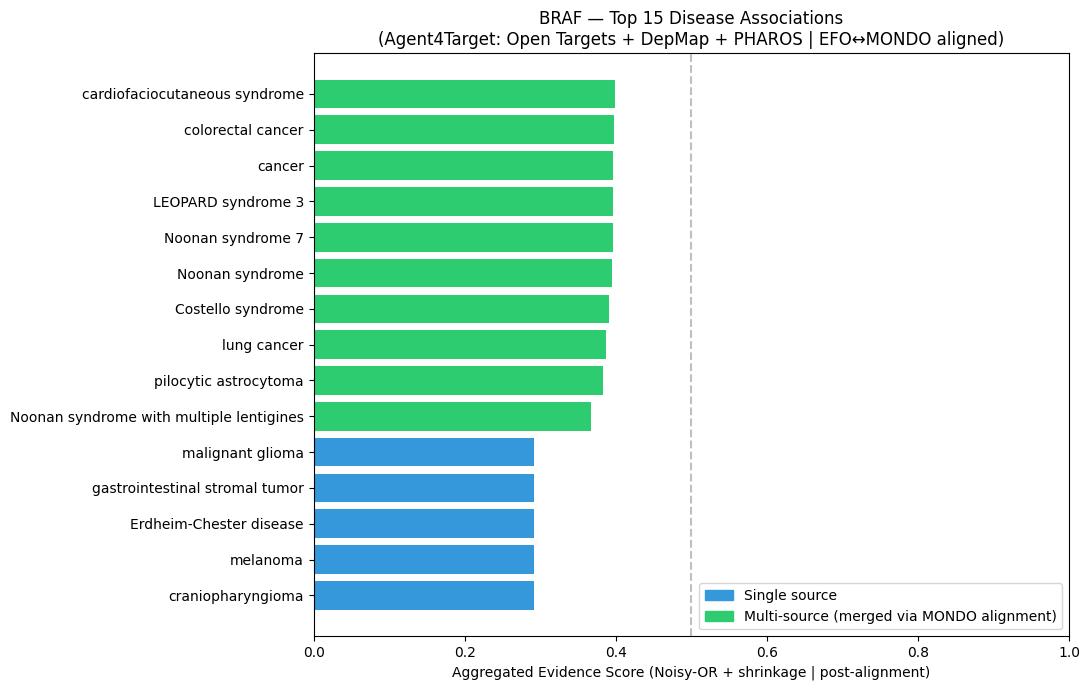

In [ ]:
top    = noisy_ranked[:15]
names  = [r["disease_name"] for r in top]
scores = [r["final_score"] or 0 for r in top]
colors = ["#2ecc71" if r["n_sources"] > 1 else "#3498db" for r in top]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(names[::-1], scores[::-1], color=colors[::-1])
ax.set_xlabel("Aggregated Evidence Score (Noisy-OR + shrinkage | MONDO-normalized)")
ax.set_title(
    f"{GENE_SYMBOL} — Top 15 Disease Associations\n"
    f"(Agent4Target: Open Targets + DepMap + PHAROS | MONDO-normalized)"
)
ax.set_xlim(0, 1.0)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)

blue  = mpatches.Patch(color="#3498db", label="Single source")
green = mpatches.Patch(color="#2ecc71", label="Multi-source (merged via MONDO normalization)")
ax.legend(handles=[blue, green], loc="lower right")

plt.tight_layout()
plt.savefig("braf_evidence_scores.png", dpi=150)
plt.show()


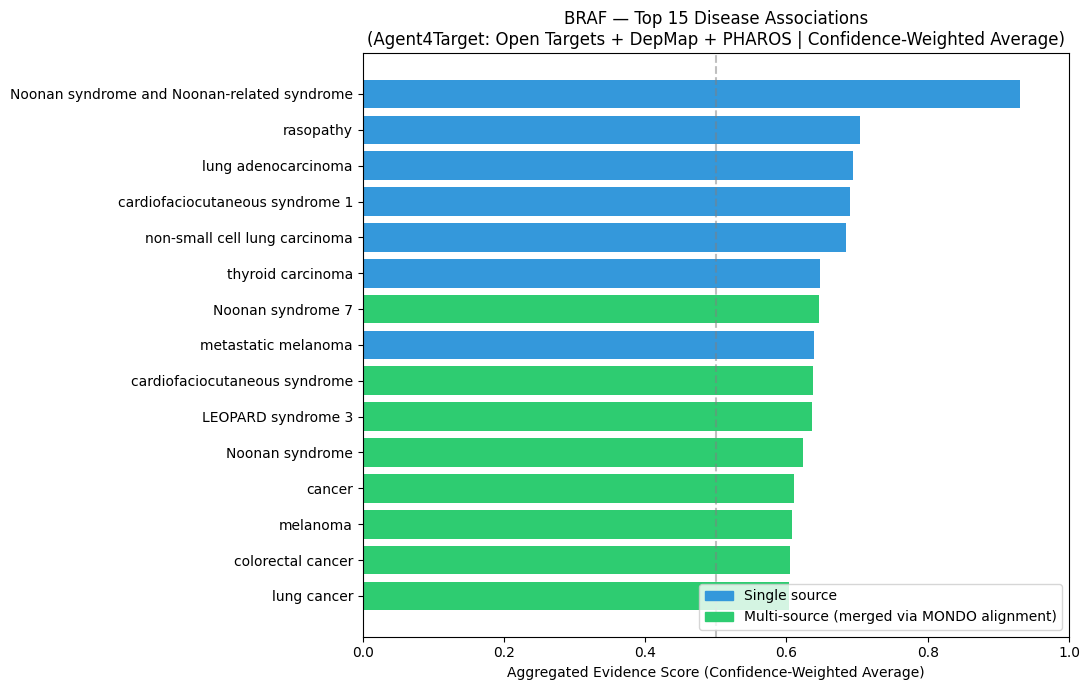

In [ ]:
# ── Simple ranked (confidence-weighted average) — mirror chart on MONDO-normalized data ──

top_simple = simple_ranked[:15]
names_s    = [r["disease_name"] for r in top_simple]
scores_s   = [r["final_score"] or 0 for r in top_simple]
colors_s   = ["#2ecc71" if r["n_sources"] > 1 else "#3498db" for r in top_simple]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(names_s[::-1], scores_s[::-1], color=colors_s[::-1])
ax.set_xlabel("Aggregated Evidence Score (Confidence-Weighted Average | MONDO-normalized)")
ax.set_title(
    f"{GENE_SYMBOL} — Top 15 Disease Associations\n"
    f"(Agent4Target: Open Targets + DepMap + PHAROS | MONDO-normalized)"
)
ax.set_xlim(0, 1.0)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)

blue  = mpatches.Patch(color="#3498db", label="Single source")
green = mpatches.Patch(color="#2ecc71", label="Multi-source (merged via MONDO normalization)")
ax.legend(handles=[blue, green], loc="lower right")

plt.tight_layout()
plt.savefig("braf_confidence_weighted_scores.png", dpi=150)
plt.show()

## 13. Evidence Type Heatmap

Each cell = strongest raw score for that disease-evidence type combination.
Reveals *what kind* of evidence drives each disease's score.

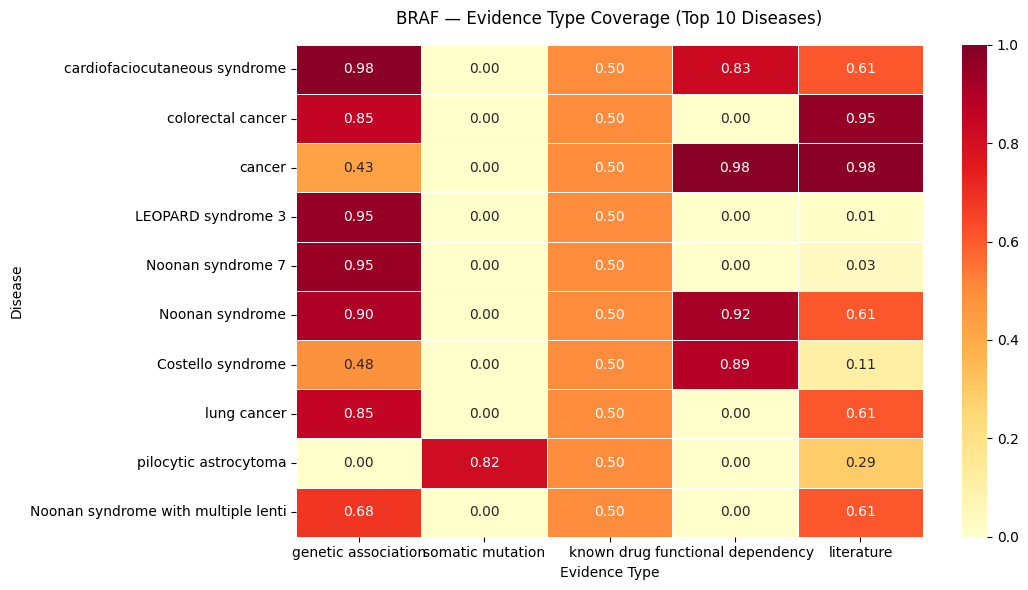

In [38]:
top10 = noisy_ranked[:10]
evidence_types = [
    "genetic_association", "somatic_mutation", "known_drug",
    "functional_dependency", "literature",
]

matrix = []
for r in top10:
    disease_recs = [rec for rec in all_records if rec.disease_id == r["disease_id"]]
    row = []
    for et in evidence_types:
        scores = [rec.raw_score for rec in disease_recs if rec.evidence_type.value == et]
        row.append(round(max(scores), 3) if scores else 0.0)
    matrix.append(row)

col_labels = [et.replace("_", " ") for et in evidence_types]
row_labels = [r["disease_name"][:35] for r in top10]

df_heat = pd.DataFrame(matrix, index=row_labels, columns=col_labels)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    df_heat, annot=True, fmt=".2f", cmap="YlOrRd",
    ax=ax, linewidths=0.5, vmin=0, vmax=1,
)
ax.set_title(f"{GENE_SYMBOL} — Evidence Type Coverage (Top 10 Diseases)", pad=15)
ax.set_xlabel("Evidence Type")
ax.set_ylabel("Disease")
plt.tight_layout()
plt.savefig("braf_evidence_heatmap.png", dpi=150)
plt.show()

## 14. Benchmark — Recall@20 with MONDO-Normalized Validation

Validates scoring on **4 known BRAF indications** after MONDO normalization.

Also compares recall before normalization vs after normalization.


In [29]:
# Benchmark (expanded MONDO validation at Recall@20 only)
if "VALIDATION_DISEASES" not in globals():
    VALIDATION_DISEASES = [
        "melanoma",
        "non-small cell lung carcinoma",
        "colorectal cancer",
        "thyroid carcinoma",
    ]

def build_validation_id_expansion(diseases: List[str], max_rows: int = 20) -> Dict[str, set]:
    """Expand each validation disease to a set of MONDO IDs via OLS4 label/synonym search."""
    expanded = {}
    for disease in diseases:
        ids = set()

        mapped = normalizer.harmonize(disease) if "normalizer" in globals() else MondoNormalizationAgent(timeout=10).harmonize(disease)
        mid = mapped.get("mondo_id", "MONDO_UNKNOWN")
        if mid.startswith("MONDO_"):
            ids.add(mid)

        docs = []
        try:
            docs = (normalizer._search if "normalizer" in globals() else MondoNormalizationAgent(timeout=10)._search)(
                q=disease,
                ontology="mondo",
                queryFields="label,synonym",
                rows=max_rows,
                fieldList="short_form,label",
            )
        except Exception:
            docs = []

        for d in docs:
            sf = d.get("short_form", "")
            if isinstance(sf, str) and sf.startswith("MONDO_"):
                ids.add(sf)

        expanded[disease] = ids
    return expanded

def expanded_recall_at_k(ranked_list: List[Dict], expanded_id_map: Dict[str, set], k: int = 20) -> Tuple[int, float, List[str]]:
    """Recall@k where each validation disease can match any expanded MONDO ID candidate."""
    top_ids = {r.get("disease_id", "") for r in ranked_list[:k]}
    hits = 0
    matched = []
    for disease, valid_ids in expanded_id_map.items():
        if valid_ids and (top_ids & valid_ids):
            hits += 1
            matched.append(disease)
    return hits, hits / max(len(expanded_id_map), 1), matched

# Build normalized ranking set
if "norm_noisy" not in globals() or "norm_simple" not in globals():
    _raw_records = ot_records + dm_records + pharos_records
    if "merged_norm" in globals() and merged_norm:
        _normalized_records = merged_norm
    else:
        _fallback_norm = MondoNormalizationAgent(timeout=10)
        if "normalize_records_with_name_fallback" in globals():
            _normalized_records = normalize_records_with_name_fallback(_raw_records, _fallback_norm)
        else:
            _normalized_records = _fallback_norm.normalize_records(_raw_records)
    norm_noisy = ScoringAgent().aggregate(_normalized_records)
    norm_simple = SimpleScoringAgent().aggregate(_normalized_records)

expanded_map = build_validation_id_expansion(VALIDATION_DISEASES, max_rows=20)
recall_k = 20
exp_noisy = expanded_recall_at_k(norm_noisy, expanded_map, k=recall_k)
exp_simple = expanded_recall_at_k(norm_simple, expanded_map, k=recall_k)

print("Expanded validation mapping (disease -> candidate MONDO IDs count)")
for d in VALIDATION_DISEASES:
    print(f"  {d:<34} : {len(expanded_map.get(d, set()))} candidates")

print(f"\nExpanded Recall@{recall_k} (MONDO candidate-set match)")
print(f"  {'Strategy':<44} {'Hits':>4}  {'Recall@20':>9}")
print(f"  {'-'*44} {'-'*4}  {'-'*9}")
print(f"  {'Normalized Noisy-OR (expanded IDs)':<44} {exp_noisy[0]:>4}  {exp_noisy[1]:>9.0%}")
print(f"  {'Normalized Confidence-Weighted (expanded IDs)':<44} {exp_simple[0]:>4}  {exp_simple[1]:>9.0%}")

print(f"\nMatched diseases at Recall@{recall_k}")
print(f"  Noisy-OR    : {exp_noisy[2]}")
print(f"  Confidence  : {exp_simple[2]}")

Expanded validation mapping (disease -> candidate MONDO IDs count)
  melanoma                           : 1 candidates
  non-small cell lung carcinoma      : 2 candidates
  colorectal cancer                  : 1 candidates
  thyroid carcinoma                  : 1 candidates

Expanded Recall@20 (MONDO candidate-set match)
  Strategy                                     Hits  Recall@20
  -------------------------------------------- ----  ---------
  Normalized Noisy-OR (expanded IDs)              2        50%
  Normalized Confidence-Weighted (expanded IDs)    4       100%

Matched diseases at Recall@20
  Noisy-OR    : ['melanoma', 'colorectal cancer']
  Confidence  : ['melanoma', 'non-small cell lung carcinoma', 'colorectal cancer', 'thyroid carcinoma']


## 15. Final Report — Machine-Readable JSON Export

Structured output consumable by any downstream system.

In [21]:
output_path = "BRAF_agent4target_report.json"
with open(output_path, "w") as f:
    f.write(report.model_dump_json(indent=2))

print(f"Report saved to {output_path}")
print(f"  Target           : {report.target_symbol}")
print(f"  Diseases ranked  : {report.n_diseases}")
print(f"  Evidence records : {report.n_evidence_records}")
print(f"  Sources          : {list(report.source_breakdown.keys())}")
print(f"  Records/source   : {report.source_breakdown}")
print(f"  Overall score    : {report.overall_score}")
print(f"  Evidence types   : {report.top_evidence_types}")

Report saved to BRAF_agent4target_report.json
  Target           : BRAF
  Diseases ranked  : 67
  Evidence records : 185
  Sources          : ['open_targets', 'depmap', 'pharos']
  Records/source   : {'open_targets': 137.0, 'depmap': 28.0, 'pharos': 20.0}
  Overall score    : 0.1644
  Evidence types   : ['functional_dependency', 'known_drug', 'somatic_mutation', 'genetic_association', 'literature']


## 16. Pipeline Execution Summary

In [22]:
print("Agent Execution Status:")
for agent_name, status in orchestrator.agent_status.items():
    s = status.get("status", "unknown")
    extra = ""
    if s == "success":
        if "n_associations" in status:
            extra = f" ({status['n_associations']} associations)"
        elif "n_cell_lines" in status:
            extra = f" ({status['n_cell_lines']} cell lines)"
        elif "tdl" in status:
            extra = f" (TDL={status['tdl']})"
    print(f"  {agent_name:<15} : {s}{extra}")

Agent Execution Status:
  open_targets    : success (1559 associations)
  depmap          : success (1186 cell lines)
  pharos          : success (20 associations)
